In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("height-weight.csv")

In [20]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


Text(0, 0.5, 'Height')

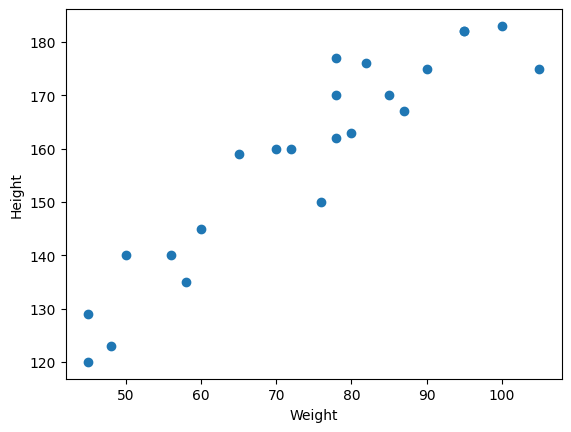

In [22]:
plt.scatter(df["Weight"], df["Height"])
plt.xlabel('Weight')
plt.ylabel('Height')

In [23]:
## divide the dataset into independent and dependent features
X = df[['Weight']]#independent
Y = df['Height'] #dependent

## Train Test Split

In [24]:
from sklearn.model_selection import train_test_split

In [25]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size = 0.2,random_state = 42)

In [26]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((18, 1), (5, 1), (18,), (5,))

In [27]:
from sklearn.preprocessing import StandardScaler
scalar = StandardScaler()

In [28]:
X_train = scalar.fit_transform(X_train)
X_test = scalar.transform(X_test)

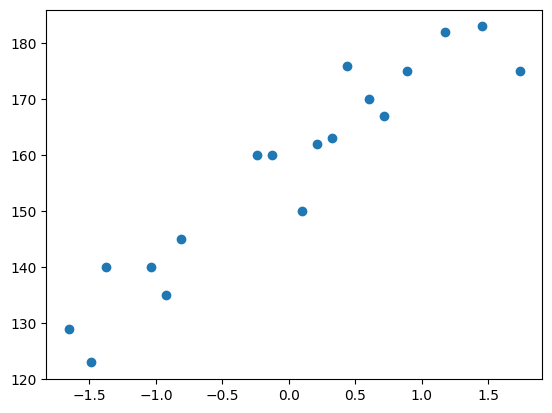

In [29]:
plt.scatter(X_train,Y_train)

## Train the Model

In [30]:
from sklearn.linear_model import LinearRegression

In [31]:
regressor = LinearRegression()

In [32]:
regressor.fit(X_train,Y_train)

LinearRegression()

In [33]:
regressor.coef_

array([17.03440872])

In [34]:
regressor.intercept_

np.float64(157.5)

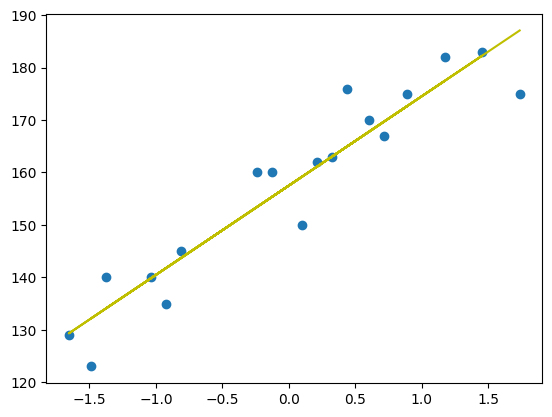

In [35]:
plt.scatter(X_train,Y_train)
plt.plot(X_train,regressor.predict(X_train),'y')

In [36]:
Y_pred_test = regressor.predict(X_test)

In [37]:
Y_pred_test

array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
       148.56507414])

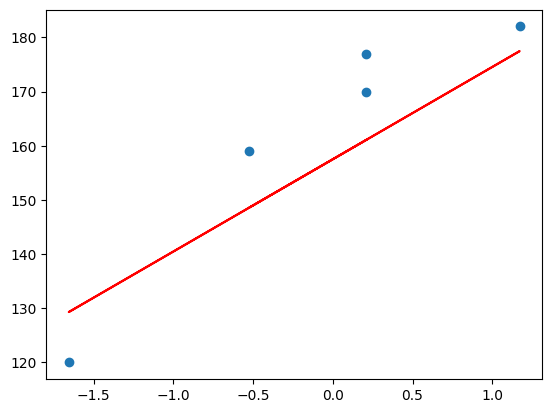

In [38]:
plt.scatter(X_test,Y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

## Performance Matrices

In [39]:
# mse,mae
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [40]:
mae = mean_absolute_error(Y_test,Y_pred_test)
mse = mean_squared_error(Y_test,Y_pred_test)
rmse = np.sqrt(mse)

In [41]:
print(mae,mse,rmse)

9.822657814519232 109.77592599051664 10.477400726827081


## r2 score

In [42]:
from sklearn.metrics import r2_score

In [43]:
score = r2_score(Y_test,Y_pred_test)

In [44]:
score

0.776986986042344

## Adjusted R square

In [45]:
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.7026493147231252

In [46]:
scaled_weight =scalar.transform([[80]])
scaled_weight

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [47]:
regressor.predict([scaled_weight[0]])

array([163.01076266])

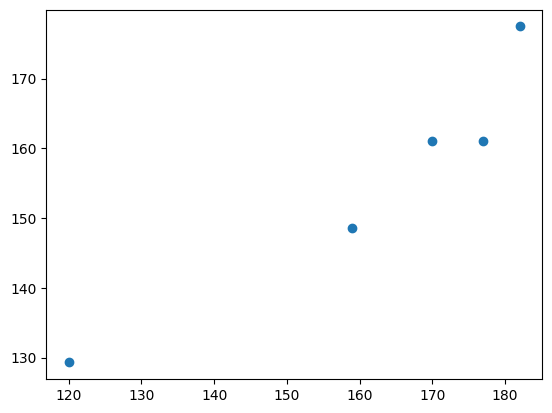

In [48]:
## Assumptions
plt.scatter(Y_test,Y_pred_test)

In [49]:
residuals = Y_test-Y_pred_test

In [50]:
residuals

,Height
15,15.915329
9,8.915329
0,-9.304156
8,4.543549
17,10.434926


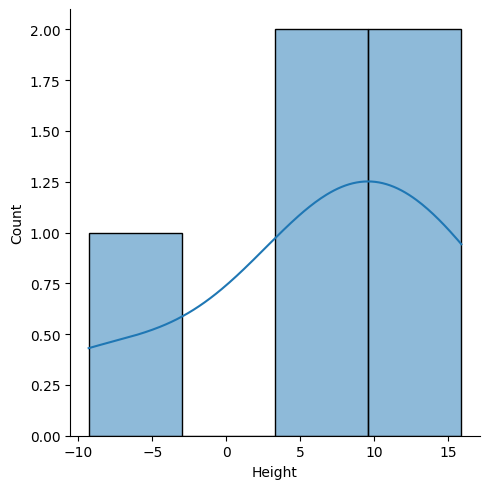

In [51]:
sns.displot(residuals,kde=True)

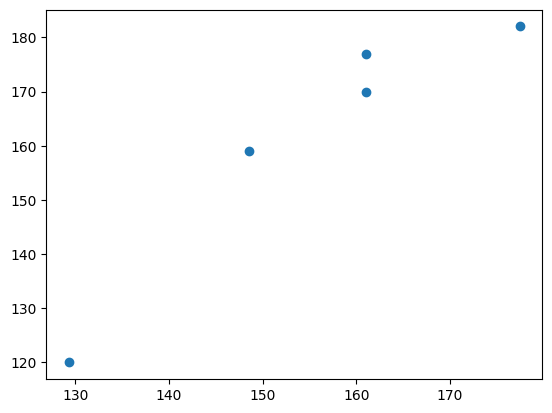

In [52]:
plt.scatter(Y_pred_test,Y_test)